In [2]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima
from sklearn.metrics import mean_squared_error

In [3]:
# Step 2: Load dataset
data = pd.read_csv("AirPassengers.csv")


In [4]:
# Step 3: Convert Month column to datetime
data['Month'] = pd.to_datetime(data['Month'])

In [5]:
# Step 4: Set Month as index
data.set_index('Month', inplace=True)

In [6]:
# Step 5: Split data into train and test
train = data[:120]
test = data[120:]

In [7]:
# Step 6: Automatically find best ARIMA parameters
auto_model = auto_arima(train['Passengers'],
                        seasonal=False,
                        trace=True,
                        suppress_warnings=True)

print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=1087.029, Time=0.80 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=1140.292, Time=0.05 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=1132.336, Time=0.15 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=1128.668, Time=0.25 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=1138.809, Time=0.04 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.30 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.59 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.79 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=inf, Time=0.79 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=1126.948, Time=0.24 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=inf, Time=0.42 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.80 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=inf, Time=0.87 sec
 ARIMA(2,1,2)(0,0,0)[0]             : AIC=inf, Time=0.67 sec

Best model:  ARIMA(2,1,2)(0,0,0)[0] intercept
Total fit time: 6.798 seco

In [8]:
# Step 7: Train ARIMA model using best parameters
model = ARIMA(train['Passengers'], order=auto_model.order)
model_fit = model.fit()

C:\Users\DARSHAN\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\DARSHAN\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\DARSHAN\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [9]:
# Step 8: Forecast
forecast = model_fit.forecast(steps=len(test))

In [10]:
# Step 9: Calculate error
rmse = np.sqrt(mean_squared_error(test['Passengers'], forecast))
print("RMSE:", rmse)

RMSE: 90.70123981371434


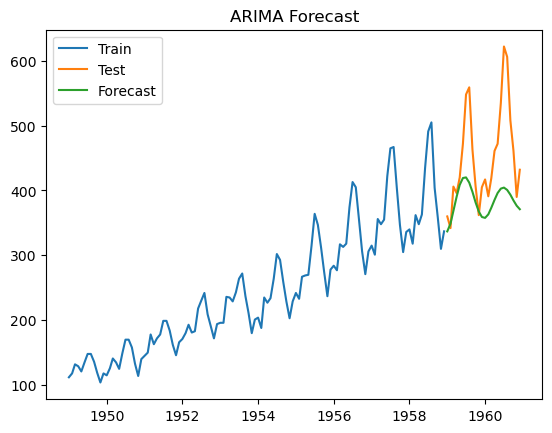

In [11]:
# Step 10: Plot results
plt.plot(train.index, train['Passengers'], label="Train")
plt.plot(test.index, test['Passengers'], label="Test")
plt.plot(test.index, forecast, label="Forecast")
plt.legend()
plt.title("ARIMA Forecast")
plt.show()